In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(4201) # fixed seed

# 30 input points evenly spaced in [-7.5, 7.5]
x_all = np.linspace(-7.5, 7.5, 30).reshape(-1, 1)

# Non-linear underlying function: cubic _ cosine
y_clean = 0.08 * x_all**3 - 0.6 * x_all + 4.0 * np.cos(0.7 * x_all)

# Add Gaussian noise to make the fit non-trivial
noise = rng.normal(loc=0.0, scale=3.0, size=x_all.shape)
y_all = y_clean + noise

# Split into training and test
x_train, y_train = x_all[::2], y_all[::2]
x_test, y_test = x_all[1::2], y_all[1::2]

In [5]:
print("x_train =\n", x_train)
print("y_train =\n", y_train)
print("x_test =\n", x_test)
print("y_test =\n", y_test)

x_train =
 [[-7.5       ]
 [-6.46551724]
 [-5.43103448]
 [-4.39655172]
 [-3.36206897]
 [-2.32758621]
 [-1.29310345]
 [-0.25862069]
 [ 0.77586207]
 [ 1.81034483]
 [ 2.84482759]
 [ 3.87931034]
 [ 4.9137931 ]
 [ 5.94827586]
 [ 6.98275862]]
y_train =
 [[-29.28667489]
 [-15.71875873]
 [-14.83013776]
 [ -6.76827492]
 [ -3.94186749]
 [ -3.60593339]
 [  1.08195839]
 [  7.48885733]
 [  4.73448444]
 [ -2.111397  ]
 [ -0.6924766 ]
 [ -2.88306046]
 [ -2.2194942 ]
 [  9.29479386]
 [ 21.11571973]]
x_test =
 [[-6.98275862]
 [-5.94827586]
 [-4.9137931 ]
 [-3.87931034]
 [-2.84482759]
 [-1.81034483]
 [-0.77586207]
 [ 0.25862069]
 [ 1.29310345]
 [ 2.32758621]
 [ 3.36206897]
 [ 4.39655172]
 [ 5.43103448]
 [ 6.46551724]
 [ 7.5       ]]
y_test =
 [[-27.72522363]
 [-16.80577045]
 [ -8.62445447]
 [ -8.31025739]
 [ -2.04394642]
 [ -1.09358955]
 [  7.95529697]
 [ -0.95485657]
 [  2.41431536]
 [  2.65629087]
 [ -1.19618328]
 [ -0.81181174]
 [  8.47635966]
 [ 17.58154987]
 [ 29.04624269]]


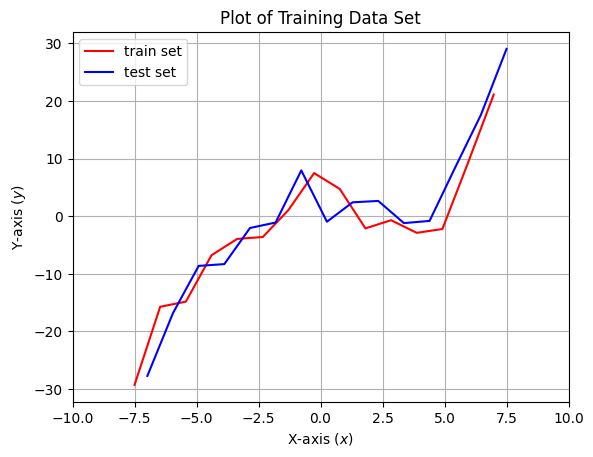

In [7]:
plt.figure()
plt.plot(x_train, y_train, color='r', label='train set')
plt.plot(x_test, y_test, color='b', label='test set' )
plt.xlabel("X-axis ($x$)")
plt.ylabel("Y-axis ($y$)")
plt.title("Plot of Training Data Set")
plt.xlim([-10, 10]) # Setting x-axis limits
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def cos_poly_features(X, K):
    X = X.flatten()
    N = X.shape[0]
    Phi = np.zeros((N, K+2))  # K+2 columns: K+1 polynomial + 1 cosine
    for k in range(K+1):
        Phi[:,k] = X**k 
    Phi[:,K+1] = np.cos(0.7 * X)  # Add cosine feature
    return Phi